In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('/content/loanpredictiondataset.csv')

In [5]:
df.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employeed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
numerical_df = df.select_dtypes(include=['number'])
correlation_matrix = numerical_df.corr()
display(correlation_matrix)

,Unnamed: 0,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
Unnamed: 0,1.000000,0.016925,0.039211,0.036462,-0.029301,-0.033772
ApplicantIncome,0.016925,1.000000,-0.116605,0.570909,-0.045306,-0.014715
CoapplicantIncome,0.039211,-0.116605,1.000000,0.188619,-0.059878,-0.002056
LoanAmount,0.036462,0.570909,0.188619,1.000000,0.039447,-0.008433
Loan_Amount_Term,-0.029301,-0.045306,-0.059878,0.039447,1.000000,0.001470
Credit_History,-0.033772,-0.014715,-0.002056,-0.008433,0.001470,1.000000


In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'Loan_ID' in categorical_cols:
    categorical_cols.remove('Loan_ID')

print(f"Categorical columns identified for analysis: {categorical_cols}")

for i in range(len(categorical_cols)):
    for j in range(i + 1, len(categorical_cols)):
        col1 = categorical_cols[i]
        col2 = categorical_cols[j]
        print(f"\n--- Contingency Table for {col1} and {col2} ---")
        contingency_table = pd.crosstab(df[col1], df[col2]) #Used to create contingency table.
        display(contingency_table)

Categorical columns identified for analysis: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employeed', 'Property_Area', 'Loan_Status']

--- Contingency Table for Gender and Married ---


Married,No,Yes
Gender,,
Female,80,31
Male,130,357



--- Contingency Table for Gender and Dependents ---


Dependents,0,1,2,3+
Gender,,,,
Female,80,19,7,3
Male,258,82,92,45



--- Contingency Table for Gender and Education ---


...

Property_Area,Rural,Semiurban,Urban
Self_Employeed,,,
No,143,191,166
Yes,26,32,24



--- Contingency Table for Self_Employeed and Loan_Status ---


Loan_Status,N,Y
Self_Employeed,,
No,157,343
Yes,26,56



--- Contingency Table for Property_Area and Loan_Status ---


Loan_Status,N,Y
Property_Area,,
Rural,69,110
Semiurban,54,179
Urban,69,133


### Gender-wise Data Visualization


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipython-input-4426522.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Count', data=gender_counts, palette='viridis')


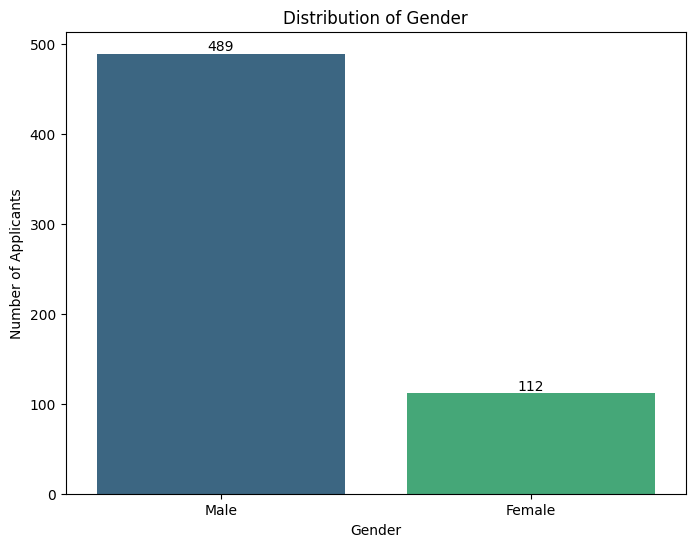

In [9]:
# Get the counts of each gender
gender_counts = df['Gender'].value_counts().reset_index()
gender_counts.columns = ['Gender', 'Count']

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Gender', y='Count', data=gender_counts, palette='viridis')

# Add labels and title
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Applicants')

# Add count labels on top of the bars
for index, row in gender_counts.iterrows():
    plt.text(index, row['Count'], str(row['Count']), color='black', ha='center', va='bottom')

plt.show()

Bar grapgh plot for dependent and married

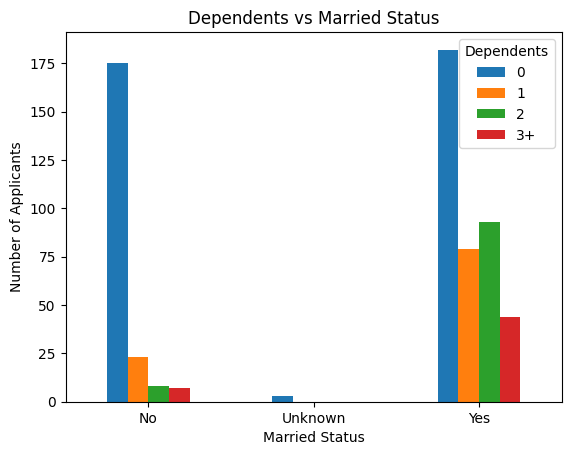

In [10]:
df["Married"] = df["Married"].fillna("Unknown")
df["Dependents"] = df["Dependents"].fillna("0")

data = df.groupby(["Married", "Dependents"]).size().unstack(fill_value=0)

data.plot(kind="bar")
plt.title("Dependents vs Married Status")
plt.xlabel("Married Status")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.show()

Box plot for Apllicant Income and Loan Status

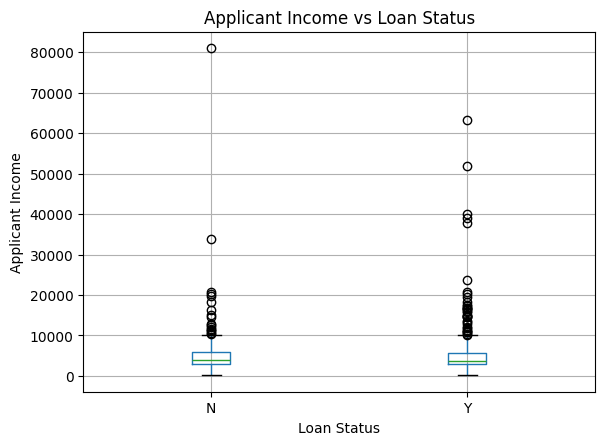

In [11]:
df.boxplot(column="ApplicantIncome", by="Loan_Status")
plt.title("Applicant Income vs Loan Status")
plt.suptitle("")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Income")
plt.show()

Bar Plot showing the relation between Education and Loan Status

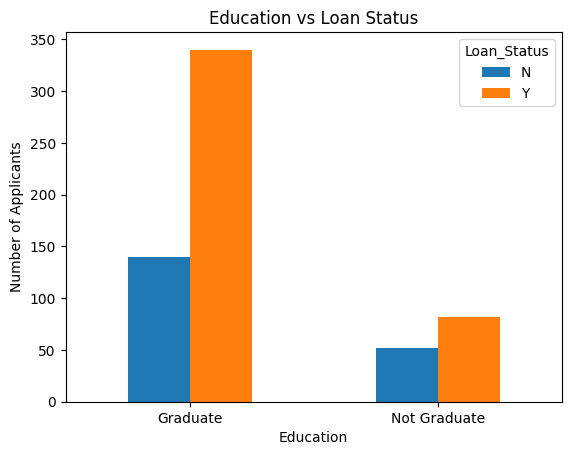

In [12]:
edu_loan = df.groupby(["Education", "Loan_Status"]).size().unstack()

edu_loan.plot(kind="bar")
plt.title("Education vs Loan Status")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.show()

Bar plot showing the relation between property area(urban, rural, semiurban) and loan status

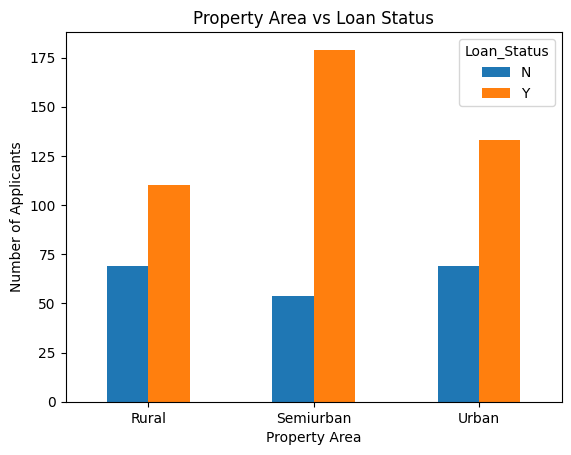

In [13]:
prop_loan = df.groupby(["Property_Area", "Loan_Status"]).size().unstack()

prop_loan.plot(kind="bar")
plt.title("Property Area vs Loan Status")
plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.show()


Bar plot showing relation between Gender and Married

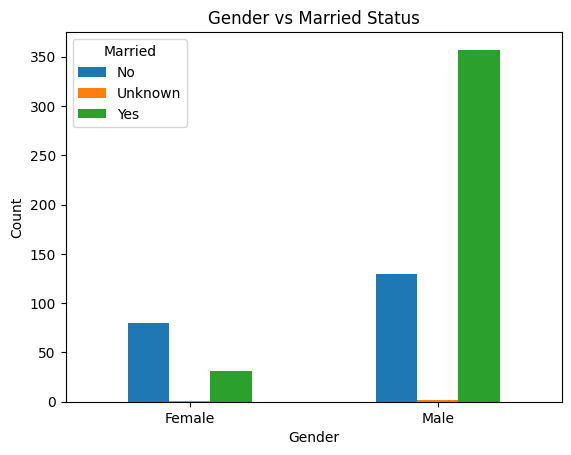

In [14]:
gender_married = df.groupby(["Gender", "Married"]).size().unstack()

gender_married.plot(kind="bar")
plt.title("Gender vs Married Status")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


Bar grapgh showing Credit History and Loan Status

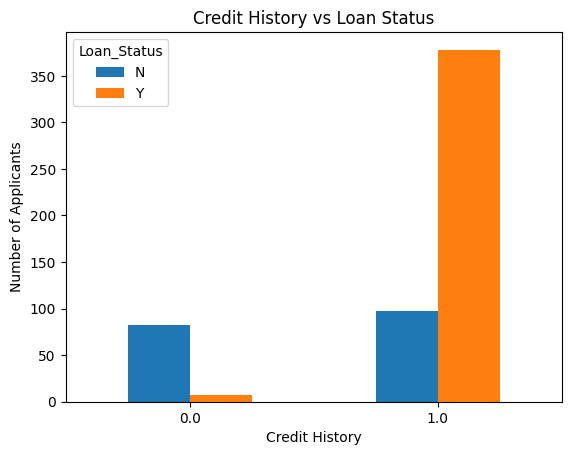

In [15]:
credit_loan = df.groupby(["Credit_History", "Loan_Status"]).size().unstack()

credit_loan.plot(kind="bar")
plt.title("Credit History vs Loan Status")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.show()


Scikit-Learn

In [16]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [17]:
df.isnull().sum()

,0
Unnamed: 0,0
Loan_ID,0
Gender,13
Married,0
Dependents,0
Education,0
Self_Employeed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22


In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train=train_test_split(df.drop(columns=['Loan_Status','Loan_ID']),df['Loan_Status'],test_size=0.2)

In [19]:
X_train

,Unnamed: 0,Gender,Married,Dependents,Education,Self_Employeed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
305,305,Male,No,0,Not Graduate,No,2000,0.0,NaN,360.0,1.0,Urban
276,276,Male,Yes,0,Graduate,No,3993,3274.0,207.0,360.0,1.0,Semiurban
52,52,Female,No,0,Graduate,No,4230,0.0,112.0,360.0,1.0,Semiurban
390,390,Male,No,3+,Graduate,No,9167,0.0,185.0,360.0,1.0,Rural
597,597,Male,No,0,Graduate,No,2987,0.0,88.0,360.0,0.0,Semiurban
...,...,...,...,...,...,...,...,...,...,...,...,...
222,222,Male,No,0,Graduate,No,2971,2791.0,144.0,360.0,1.0,Semiurban
359,359,Male,Yes,3+,Graduate,No,5167,3167.0,200.0,360.0,1.0,Semiurban
314,314,NaN,Yes,0,Graduate,No,2473,1843.0,159.0,360.0,1.0,Rural
477,477,NaN,Yes,2,Graduate,No,2873,1872.0,132.0,360.0,0.0,Semiurban


In [20]:
#Simple Imputer: Fill all the null values in column
si=SimpleImputer(strategy='most_frequent')

X_train_Gender=si.fit_transform(X_train[['Gender','Married','Dependents','Self_Employeed','LoanAmount','Loan_Amount_Term','Credit_History']])

X_test_Gender=si.fit_transform(X_test[['Gender','Married','Dependents','Self_Employeed','LoanAmount','Loan_Amount_Term','Credit_History']])

X_train_Gender.shape

(491, 7)

In [21]:
# OrdinalEncoder:
# The Dependents column has already been imputed as part of X_train_fever and X_test_fever.
# We need to extract the imputed 'Dependents' column from these arrays.
# 'Dependents' is the 3rd column (index 2) in the list used for si.fit_transform:
# ['Gender','Married','Dependents','Self_Employeed','LoanAmount','Loan_Amount_Term','Credit_History']

# Extract the imputed 'Dependents' column
X_train_imputed_dependents = X_train_Gender[:, 2].reshape(-1, 1)
X_test_imputed_dependents = X_test_Gender[:, 2].reshape(-1, 1)

oe=OrdinalEncoder(categories=[['0','1','2','3+']])
X_train_dependents=oe.fit_transform(X_train_imputed_dependents)
X_test_dependents=oe.transform(X_test_imputed_dependents)

X_train_dependents.shape

(491, 1)

In [22]:
# One hot encoding -> Loan Amount & Credit History
ohe=OneHotEncoder(drop='first',sparse_output=False)
X_train_LoanAmount_Credit_History=ohe.fit_transform(X_train[['Property_Area']])

# testing the model
X_test_LoanAmount_Credit_History=ohe.transform(X_test[['Property_Area']])

X_train_LoanAmount_Credit_History.shape

(491, 2)

In [23]:
# Convert X_train and X_test DataFrames to numpy arrays
# Loan_ID was already dropped during the train_test_split step.
X_train_Loan_Status=X_train.values

# Convert X_test DataFrame to numpy array
X_test_Loan_Status=X_test.values

X_train_Loan_Status.shape

(491, 12)

In [24]:
# transformed the data
X_train_transformed=np.concatenate((X_train_LoanAmount_Credit_History,X_train_Loan_Status,X_train_Gender,X_train_dependents),axis=1)

#testing the data
X_test_transformed=np.concatenate((X_test_LoanAmount_Credit_History,X_test_Loan_Status,X_test_Gender,X_test_dependents),axis=1)

X_train_transformed.shape

(491, 22)

In [25]:
# Column Transform
from sklearn.compose import ColumnTransformer

In [29]:
transformer = ColumnTransformer(transformers=[
    ('tnf1',SimpleImputer(strategy='most_frequent'),['Gender']),
    ('tnf2',OrdinalEncoder(categories=[['0','1','2','3+']]),['Dependents']),
    ('tnf3',OneHotEncoder(sparse_output=False,drop='first'),['Property_Area'])
],remainder='passthrough')

In [30]:
transformer.fit_transform(X_train).shape

(491, 13)

In [31]:
transformer.transform(X_test).shape

(123, 13)